<a href="https://colab.research.google.com/github/InfiniteLobster/CDA-case1/blob/main/case_workspace.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
!pip install xgboost joblib -q

In [16]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [17]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import Lasso, Ridge, ElasticNet, LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.decomposition import PCA

%matplotlib inline
sns.set_style("whitegrid")

In [18]:
# Load datasets
train_df = pd.read_csv("/content/drive/MyDrive/case-data/case1Data.csv")
xnew_df = pd.read_csv("/content/drive/MyDrive/case-data/case1Data_Xnew.csv")

print("Training data shape:", train_df.shape)
print("New data shape:", xnew_df.shape)

Training data shape: (100, 101)
New data shape: (1000, 100)


In [19]:
# Split features and target
y_train = train_df.iloc[:,0]
X_train = train_df.iloc[:,1:]
X_new = xnew_df

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print(X_train.head())
print(y_train.head())

X_train shape: (100, 100)
y_train shape: (100,)
       x_01       x_02      x_03       x_04       x_05      x_06       x_07  \
0  6.359019 -13.367120 -2.483750  -6.641891  11.733539       NaN -17.085361   
1  3.873664  -8.470389 -3.055012        NaN  11.420983  1.822330 -13.694100   
2  5.275824 -12.070531 -1.366168  -4.819100  10.721527 -5.125992 -17.476865   
3  4.430110  -4.467975 -0.730736 -10.047104  11.498539 -2.870260 -14.033012   
4  3.116458  -8.518713 -6.796050        NaN   7.646285 -3.118309 -13.102567   

        x_08       x_09       x_10  ...       x_91       x_92      x_93  \
0  22.194764  16.827888 -10.367142  ... -10.200888   3.980048 -4.433274   
1  22.738654  20.307503  -2.859097  ...  -9.740207        NaN -2.629314   
2        NaN  15.963889  -3.257940  ... -14.501970  10.054005       NaN   
3  18.225190  10.409488  -5.616061  ... -11.086963   2.019726 -8.531959   
4  22.801217  16.680208  -3.357765  ...  -9.117422   6.627601 -2.805531   

       x_94       x_95  C_

In [20]:
print(X_new.shape)

(1000, 100)


In [21]:
# Identify categorical columns
cat_cols = [col for col in X_train.columns if col.startswith("C_")]
num_cols = [col for col in X_train.columns if not col.startswith("C_")]

print("Number of numerical columns:", len(num_cols))
print("Number of categorical columns:", len(cat_cols))

Number of numerical columns: 95
Number of categorical columns: 5


In [22]:
# Check missing values
missing_count = X_train.isnull().sum()
missing_percent = (missing_count / len(X_train))*100

missing_df = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing %": missing_percent
}).sort_values("Missing %", ascending=False)

print(missing_df[missing_df["Missing Count"] > 0])

      Missing Count  Missing %
x_85             27       27.0
x_12             24       24.0
x_65             22       22.0
C_02             22       22.0
C_01             22       22.0
...             ...        ...
x_89              9        9.0
x_80              9        9.0
x_28              8        8.0
x_61              7        7.0
x_76              6        6.0

[100 rows x 2 columns]


In [23]:
# Numeric preprocessing (scaled)
numeric_scaled = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [24]:
# Categorical preprocessing
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [25]:
# Preprocessor for scaled models (Lasso, ridge, elastic net and PCR)
preprocessor_scaled = ColumnTransformer([
    ("num", numeric_scaled, num_cols),
    ("cat", categorical_pipeline, cat_cols)
])

In [26]:
# Preprocessor for random forest (no scaling)
numeric_unscaled = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

preprocessor_unscaled = ColumnTransformer([
    ("num", numeric_unscaled, num_cols),
    ("cat", categorical_pipeline, cat_cols)
])

Processed dataset shape: (100, 116)


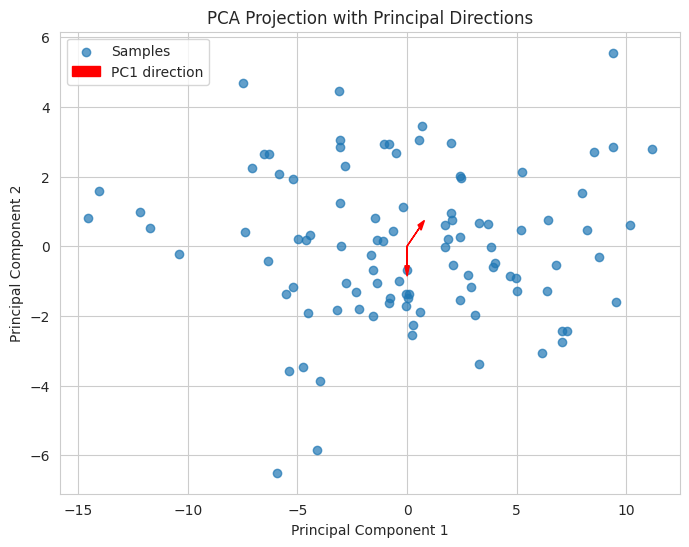

In [28]:
# PCA visualizations

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

X_scaled = preprocessor_scaled.fit_transform(X_train)
print("Processed dataset shape:", X_scaled.shape)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], alpha=0.7, label="Samples")


# Plot principal directions
for i, comp in enumerate(pca.components_):
    plt.arrow(
        0, 0,
        comp[0]*5,
        comp[1]*5,
        color="red",
        head_width=0.2,
        label=f"PC{i+1} direction" if i == 0 else None
    )


plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Projection with Principal Directions")
plt.legend()

plt.show()

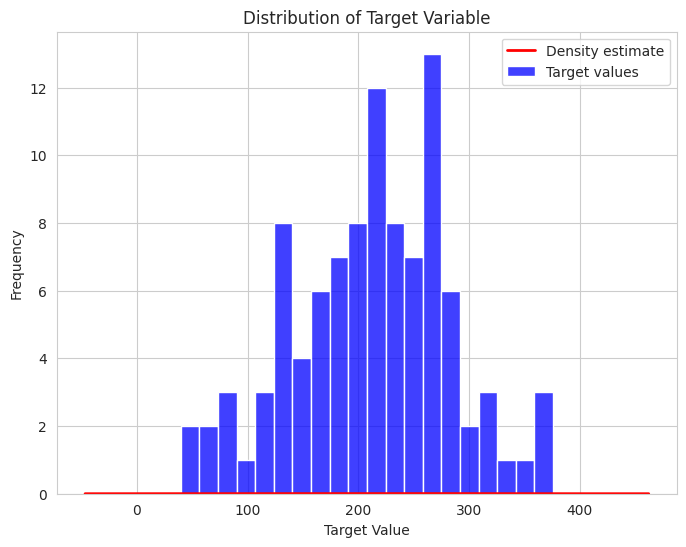

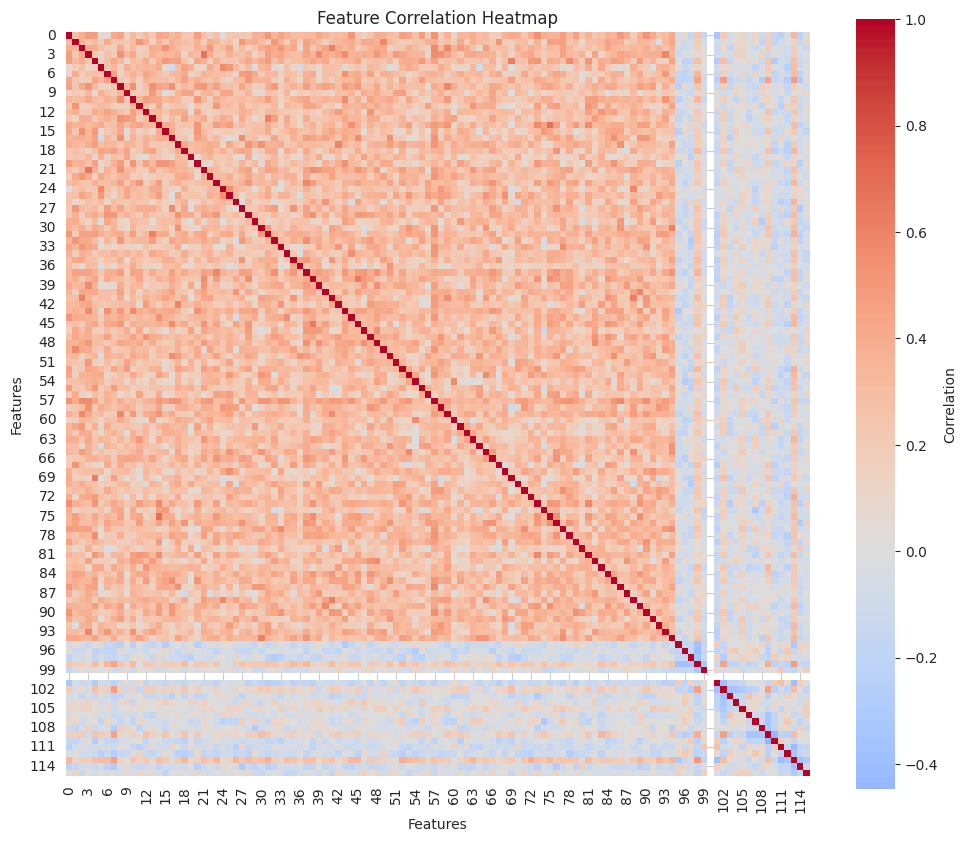

In [31]:
# Visualization

# Histogram
plt.figure(figsize=(8,6))

sns.histplot(y_train, bins=20, color="blue", label="Target values")
sns.kdeplot(y_train, color="red", linewidth=2, label="Density estimate")

plt.title("Distribution of Target Variable")
plt.xlabel("Target Value")
plt.ylabel("Frequency")

plt.legend()
plt.show()

# Heatmap
X_scaled_df = pd.DataFrame(X_scaled)

# Compute correlation matrix
corr_matrix = X_scaled_df.corr()

# Plot heatmap
plt.figure(figsize=(12,10))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    square=True,
    cbar_kws={"label": "Correlation"}
)

plt.title("Feature Correlation Heatmap")
plt.xlabel("Features")
plt.ylabel("Features")


plt.show()

In [ ]:
# Pipeline creation
def create_model_pipeline(model_name, **params):

    if model_name in ["lasso","ridge","elasticnet","pcr"]:
        preprocessor = preprocessor_scaled
    elif model_name == "randomforest":
        preprocessor = preprocessor_unscaled
    else:
        raise ValueError("Unknown model")

    if model_name == "lasso":
        model = Lasso(**params)

    elif model_name == "ridge":
        model = Ridge(**params)

    elif model_name == "elasticnet":
        model = ElasticNet(**params)

    elif model_name == "randomforest":
        model = RandomForestRegressor(**params)

    elif model_name == "pcr":
        n_components = params.get("n_components",10)

        model = Pipeline([
            ("pca", PCA(n_components=n_components)),
            ("regression", LinearRegression())
        ])

    pipeline = Pipeline([
        ("preprocessing", preprocessor),
        ("model", model)
    ])

    return pipeline

In [ ]:
# Example pipelines
lasso_pipe = create_model_pipeline("lasso", alpha=1.0)

ridge_pipe = create_model_pipeline("ridge", alpha=1.0)

elastic_pipe = create_model_pipeline("elasticnet", alpha=0.1, l1_ratio=0.5)

rf_pipe = create_model_pipeline("randomforest", n_estimators=100, random_state=42)

pcr_pipe = create_model_pipeline("pcr", n_components=10)

In [ ]:
# Rough pipeline test on small sample
X_sample = X_train.head(20)
y_sample = y_train.head(20)

for pipe in [lasso_pipe, ridge_pipe, elastic_pipe, rf_pipe, pcr_pipe]:

    pipe.fit(X_sample, y_sample)

    preds = pipe.predict(X_sample)

    mse = np.mean((y_sample - preds)**2)

    print("Test MSE:", mse)